<a href="https://colab.research.google.com/github/jdtoscano94/NABLA-SciML/blob/main/Burgers_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clone the repository and Setup the Environment

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd /content/drive/MyDrive/

/content/drive/MyDrive


In [4]:
%cd NABLA-SciML/
! pip install jax[cuda]
! pip install -e .
! pip install numpy==2.0.2 --force-reinstall
! pip install vtk

/content/drive/MyDrive/NABLA-SciML
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 39.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-cuda-nvcc-cu12
    Found existing installation: nvidia-cuda-nvcc-cu12 12.5.82
    Uninstalling nvidia-cuda-nvcc-cu12-12.5.82:
      Successfully uninstalled nvidia-cuda-nvcc-cu12-12.5.82
Obtaining file:///content/drive/MyDrive/NABLA-SciML
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.6/73.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 91.1 MB/s eta 0:00:00
  Building editable for Crunch (pyproject.toml) ... done
  Created wheel for Crunch: filename=crunch-0.1.0-0.editable-py3-none-any.whl size=5221 sha256=92008d70a21b12134269bd3840feb70b37e16725cd62bbccfd7ce8298e2fbe81
  Stored in directory: /tmp/pip-ep

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 75.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.3
    Uninstalling numpy-2.4.3:
      Successfully uninstalled numpy-2.4.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pydoe 0.9.7 requires numpy>=2.2.6, but you have numpy 2.0.2 which is incompatible.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.6/145.6 MB 8.4 MB/s eta 0:00:00


In [5]:
import os
import sys
import time
import random
from functools import partial
from typing import Sequence, Callable

# --- JAX, Flax, and Optax ---
import jax
import jax.numpy as jnp
from jax import Array
from jax import jit, jvp, vjp, value_and_grad, lax, vmap
from jax.flatten_util import ravel_pytree
from flax import linen as nn
import optax

# --- NumPy, SciPy, and Plotting ---
import numpy as np
import scipy

print(f"NumPy version before scipy.io import: {np.__version__}")
print(f"SciPy version before scipy.io import: {scipy.__version__}")

import scipy.io as sio
from scipy import sparse
from scipy.linalg import cholesky, LinAlgError
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as colors
import argparse

# --- Other Third-Party ---
from tqdm import tqdm
from pyDOE import lhs

# --- Local Application Libraries ---
from Crunch.Models.layers import *
from Crunch.Auxiliary.metrics import relative_l2
from Crunch.Optimizers.minimize import minimize
from Crunch.Auxiliary.utils import static_options_SSBroyden


NumPy version before scipy.io import: 2.0.2
SciPy version before scipy.io import: 1.16.3


/tmp/ipykernel_712/1291779132.py:34: DeprecationWarning: Importing `pyDOE` is deprecated and will be removed in a future release. Please import `pydoe` instead.
  from pyDOE import lhs


In [6]:

#from jax import config
jax.config.update("jax_enable_x64", True)
# force jax to use one device
os.environ["CUDA_VISIBLE_DEVICES"]="0"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"]="false"

### Cell 2: Hyperparameter Configuration (argparse)

In [7]:
# Set up argument parser
parser = argparse.ArgumentParser(description='Tuning Parameters')
parser.add_argument('--Equation', type=str, default='Burgers', help='Name of equation')
parser.add_argument('--Name', type=str, default='SS_Broyden', help='Name of the experiment')
parser.add_argument('--NC', type=int, default=200000, help='Number of samples for training')
parser.add_argument('--NI', type=int, default=512, help='Number of iterations')
parser.add_argument('--NB', type=int, default=512, help='Batch size')
parser.add_argument('--NC_TEST', type=int, default=100, help='Number of test samples')
parser.add_argument('--SEED', type=int, default=9999, help='Random seed')
parser.add_argument('--EPOCHS', type=int, default=5000, help='Number of training epochs')
parser.add_argument('--N_LAYERS', type=int, default=3, help='Number of layers in the network')
parser.add_argument('--HIDDEN', type=int, default=30, help='Number of hidden units per layer')
parser.add_argument('--FEATURES', type=int, default=1, help='Feature size')
parser.add_argument('--embedding_degree', type=int, default=5, help='Degree of features')
parser.add_argument('--lr_fact', type=float, default=0.2, help='Scale Lr')
parser.add_argument('--eta', type=float, default=0.01, help='Learning rate or step size for adaptive gamma')
parser.add_argument('--gamma', type=float, default=0.999, help='Decay rate for adaptive gamma')
parser.add_argument('--gamma_bfgs', type=float, default=0.1, help='Decay rate for adaptive gamma')
parser.add_argument('--gamma_grads', type=float, default=0.99, help='Decay rate for adaptive gamma')
parser.add_argument('--alpha', type=float, default=0.999, help='Decay rate for exponential moving average')
parser.add_argument('--cap_RBA', type=float, default=20, help='Cap limit for RBA')
parser.add_argument('--max_RBA', type=float, help='Maximum RBA value, default calculated as eta / (1 - gamma)')
parser.add_argument('--vrba_potential', type=str, default='exponential', help='In case')
parser.add_argument('--decay_rate', type=float, default=0.9, help='Decay rate for learning rate schedule')
parser.add_argument('--LR', type=float, default=1e-3, help='Initial learning rate')
parser.add_argument('--decay_step', type=int,default=5000, help='Decay step size')
parser.add_argument('--Note', type=str, default='', help='In case')
parser.add_argument('--batch_size', type=int, default=20000, help='batch_size')
parser.add_argument('--k_samp', type=float, default=1.0, help='Enhance outliers smoothing factor')
parser.add_argument('--c_samp', type=float, default=0.0, help='homogenize')
parser.add_argument('--phi', type=float, default=1, help='Enhance outliers smoothing factor')
parser.add_argument('--c_log', type=float, default=1.0, help='homogenize')
parser.add_argument('--N_change', type=int, default=100, help='homogenize')
# Parse arguments and display them
args, unknown = parser.parse_known_args()
for arg, value in vars(args).items():
    print(f'{arg}: {value}')
# Data
NC = args.NC
NI = args.NI
NB = args.NB
NC_TEST = args.NC_TEST
#Representation Model
#- Input transfromations
embedding_degree = args.embedding_degree
# - Architecture
N_LAYERS = args.N_LAYERS # Number of Layers
HIDDEN = args.HIDDEN #hidden neurons per layer
FEATURES = args.FEATURES # Number of output fetures
# - 1st Stage Optmization
## Adam
EPOCHS = args.EPOCHS
eta = args.eta
decay_rate = args.decay_rate
LR = args.LR
lr0 = LR
decay_step = args.decay_step
## vRBA Params
gamma = args.gamma
alpha = args.alpha
c_log=args.c_log
phi=args.phi
##  We use a self scaling algoirhtm to automatically tune the global weights and to increase the cap of RBA to improve learning dunamics
max_RBA0 = args.max_RBA if args.max_RBA is not None else eta / (1 - gamma)
cap_RBA = args.cap_RBA
gamma_grads=args.gamma_grads
## vRBA Params Second order_ Sampling + SSBroycen
k_samp_bfgs = args.k_samp
c_samp_bfgs = args.c_samp
Nchange = args.N_change  # Number of SSBroyden steps before resampling
batch_size=args.batch_size
Nbfgs = 100000  # Number of SSBroyden BFGs iterations
# random key
SEED = args.SEED
key = jax.random.PRNGKey(SEED)
key, subkey = jax.random.split(key, 2)
# Initialize NumPy seed
np.random.seed(SEED)
# Name of the project
args.Name=args.Name+f'vRBA-phi:{phi:.2f}-c_log:{c_log:.2f}-bs:{batch_size}_k:{k_samp_bfgs:.2f}_N:{Nchange:.2f}_Seed:{SEED}'+args.Note
print(args.Name)
#Define folder
file_path = os.getcwd()

project_root = os.path.dirname(file_path)
# Option B: Save Results inside your current NABLA-SciML folder (recommended)
args.Name = project_root + '/Results/' + args.Equation + '/' + args.Name + '/'
os.makedirs(args.Name, exist_ok=True)

Equation: Burgers
Name: SS_Broyden
NC: 200000
NI: 512
NB: 512
NC_TEST: 100
SEED: 9999
EPOCHS: 5000
N_LAYERS: 3
HIDDEN: 30
FEATURES: 1
embedding_degree: 5
lr_fact: 0.2
eta: 0.01
gamma: 0.999
gamma_bfgs: 0.1
gamma_grads: 0.99
alpha: 0.999
cap_RBA: 20
max_RBA: None
vrba_potential: exponential
decay_rate: 0.9
LR: 0.001
decay_step: 5000
Note: 
batch_size: 20000
k_samp: 1.0
c_samp: 0.0
phi: 1
c_log: 1.0
N_change: 100
SS_BroydenvRBA-phi:1.00-c_log:1.00-bs:20000_k:1.00_N:100.00_Seed:9999


### Cell 3: Data Loading and Ground Truth Definition


In [8]:
available_data_sets_path='/content/drive/MyDrive/NABLA-SciML/vRBA_variational_residual_based_attention_PINNs_Operator_learning/PINN/Data/'
data = scipy.io.loadmat(available_data_sets_path+'burgers.mat')
print(data.keys())
Exact = data['usol'].T
Exact0 = np.real(Exact).astype(jnp.float64)
t0 = data['t'].flatten()[:,None].astype(jnp.float64)
x0 = data['x'].flatten()[:,None].astype(jnp.float64)
T, X = np.meshgrid(t0, x0)
# Ground Truth (to compute relative errors)
t = T.flatten()[:,None]
x = X.flatten()[:,None]
u_gt = Exact0.flatten()[:,None]


dict_keys(['__header__', '__version__', '__globals__', 't', 'usol', 'x'])


## Cell 4: Data Processing, Sampling, and Visualization

/tmp/ipykernel_712/1078274248.py:42: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('Boundaries_data.png',dpi=300)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


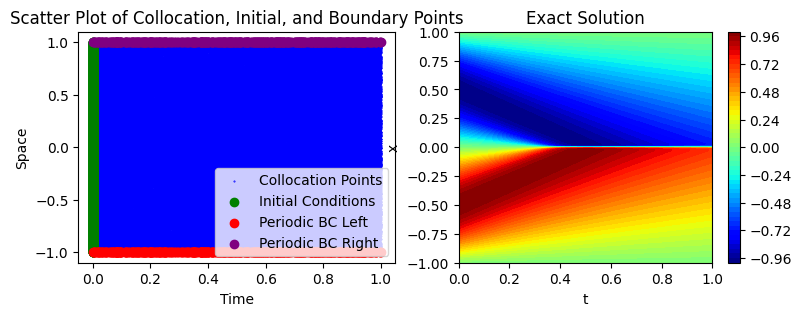

In [9]:
# Collocation points
lb_D = jnp.array([t0.min(), x0.min()])
ub_D = jnp.array([t0.max(), x0.max()])
# Generate collocation points and ensure they are float64
X_c = lb_D + (ub_D - lb_D) * lhs(2, NC)
X_c = X_c.astype(jnp.float64)
tc = X_c[:, 0:1]
xc = X_c[:, 1:2]
# Initial conditions
ti = T[:, 0:1]
xi = X[:, 0:1]
ui = -jnp.sin(jnp.pi * xi)
# Boundary Conditions (not used in the 2nd order part, but good practice)
keys = jax.random.split(key, 13)
tb = jax.random.uniform(keys[3], (NB, 1), minval=lb_D[0], maxval=ub_D[0]).astype(jnp.float64)
# Periodic Boundary Conditions
tb_periodic = jax.random.uniform(keys[4], (NB, 1), minval=lb_D[0], maxval=ub_D[0]).astype(jnp.float64)
xb_periodic_left = jnp.ones_like(tb_periodic) * lb_D[1]
xb_periodic_right = jnp.ones_like(tb_periodic) * ub_D[1]
# This data tuple is now consistently float64
train_data = tc, xc, ti, xi, ui, tb_periodic, xb_periodic_left, xb_periodic_right
lambdas = tc * 0 + 0.1
# Plotting code
fig = plt.figure(figsize=(9, 3))
# Scatter plot for collocation, initial, and boundary points
ax1 = fig.add_subplot(121)
ax1.scatter(tc, xc, color='blue', label='Collocation Points',s=0.2)
ax1.scatter(ti, xi, color='green', label='Initial Conditions')
ax1.scatter(tb_periodic, xb_periodic_left, color='red', label='Periodic BC Left')
ax1.scatter(tb_periodic, xb_periodic_right, color='purple', label='Periodic BC Right')
ax1.set_xlabel('Time')
ax1.set_ylabel('Space')
ax1.set_title('Scatter Plot of Collocation, Initial, and Boundary Points')
ax1.legend()
# Surface plot for Exact solution
ax2 = fig.add_subplot(122)
contour = ax2.contourf(T, X, Exact0, cmap='jet', levels=50)  # Filled contour plot with 50 levels
fig.colorbar(contour)  # Add color bar to show scale
ax2.set_xlabel('t')
ax2.set_ylabel('x')
ax2.set_title('Exact Solution')
plt.savefig('Boundaries_data.png',dpi=300)
plt.show()

n_batches_snr = 100
NC_SNR = batch_size * n_batches_snr
X_snr = lb_D + (ub_D - lb_D) * lhs(2, NC_SNR)
X_snr = X_snr.astype(jnp.float64)
X_batches_snr = jnp.array_split(X_snr, n_batches_snr)


## Cell 5: Model Architecture Definition (The PINN Structure)

In [10]:

class Periodic_Fourier_Features(nn.Module):
    kmax: int = 1
    Lx: float = 2.0
    @nn.compact
    def __call__(self, X: Array) -> Array:
        ks = jnp.arange(1, self.kmax + 1)
        Xper = 2 * jnp.pi * jnp.matmul(X, ks[None, :]) / self.Lx
        xcos = jnp.cos(Xper)
        xsin = jnp.sin(Xper)
        Xper = jnp.concatenate([xcos, xsin], axis=1)
        return Xper
class MLP(nn.Module):
    features: Sequence[int]
    @nn.compact
    def __call__(self, x):
        for i, feat in enumerate(self.features):
            x = nn.Dense(feat)(x)
            if i != len(self.features) - 1:
                x = nn.tanh(x)
        return x
class PINN(nn.Module):
    features: Sequence[int]
    lb: jnp.ndarray
    ub: jnp.ndarray
    embedding_degree: int = 1
    Lx: float = 1.0  # Correct period for x in [0, 1]

    def setup(self):
        self.embedding = Periodic_Fourier_Features(kmax=self.embedding_degree, Lx=self.Lx)
        self.main_body = MLP(features=self.features)

    @nn.compact
    def __call__(self, t: Array, x: Array) -> Array:
        # Differentiable normalization as per strategy
        t_norm = (t - self.lb[0]) / (self.ub[0] - self.lb[0])
        x_norm = (x - self.lb[1]) / (self.ub[1] - self.lb[1])

        # Apply periodic embedding to normalized x
        x_embedded = self.embedding(x_norm)

        # Concatenate normalized time t with the embedded x features
        X_concat = jnp.concatenate([t_norm, x_embedded], axis=-1)

        # Pass through the MLP
        H = self.main_body(X_concat)

        # Apply hard constraint ansatz using original t and x
        u = jnp.sin(-jnp.pi * x) + t * H
        return u


## Cell 6: Model and Optimizer Initialization

In [11]:
feat_sizes = tuple([HIDDEN for _ in range(N_LAYERS)] + [FEATURES])
print(feat_sizes)
# make & init model
model = PINN(features=feat_sizes, lb=lb_D, ub=ub_D, embedding_degree=embedding_degree)
params = model.init(subkey, jnp.ones((NC, 1), dtype=jnp.float64), jnp.ones((NC, 1), dtype=jnp.float64))
params = jax.tree_util.tree_map(lambda x: x.astype(jnp.float64), params)
optimizers = {}
for key_params in params['params'].keys():
    optimizers[key_params] = optax.adam(optax.exponential_decay(lr0, decay_step, decay_rate, staircase=False))
# Initialize optimizer states for each parameter group
states = {key_params: optim.init(params['params'][key_params]) for key_params, optim in optimizers.items()}
# forward & loss function
apply_fn = jax.jit(model.apply)
total_params = sum(x.size for x in jax.tree_util.tree_leaves(params))
print(total_params )


(30, 30, 30, 1)
2251


## Cell 7: PDE Residual Definition

In [12]:
def Viscous_Burgers(params, t, x, nu, apply_fn):
    u = apply_fn(params, t, x)
    v_t = jnp.ones_like(t)
    v_x = jnp.ones_like(x)

    # First derivatives using jvp
    ut = jvp(lambda t_val: apply_fn(params, t_val, x), (t,), (v_t,))[1]

    # Conservative flux derivative: d/dx(0.5 * u^2)
    flux_fn = lambda u_val: 0.5 * u_val**2
    flux_x = jvp(lambda x_val: flux_fn(apply_fn(params, t, x_val)), (x,), (v_x,))[1]

    uxx = hvp_fwdfwd(lambda x_val: apply_fn(params, t, x_val), (x,), (v_x,))

    return ut + flux_x - nu * uxx


PDE_residuals=Viscous_Burgers

## Cell 8: vRBA Steps 1 & 3 - Weight & Multiplier Generation

In [13]:
@partial(jit, static_argnums=(2, 3))
def get_exact_epsilon(values, r_max, potential_type, n_newton=5):
    """
    Solves for the exact epsilon in FLOAT64.
    Safety clamps relaxed to 1e-16 to allow for sharper distributions.
    """
    N = values.shape[0]

    # SAFETY: Prevent 0.0 guess.
    r_max_safe = jnp.maximum(r_max, 1e-16)

    # 1. Initialization (Asymptotic Approximations)
    if potential_type == 'cosh':
        # Constraint: mean(sinh(r/eps)) = 1
        eps_guess = r_max_safe / (jnp.log(2.0 * N) + 1e-16)

    elif potential_type == 'superexp':
        # Constraint: mean( u * exp(u^2) ) = 1
        eps_guess = r_max_safe / jnp.sqrt(jnp.log(N) + 1e-16)

    elif potential_type == 'logarithmic':
        # Constraint: mean( log(r/eps + 1) ) = 1
        # Approx: eps ~ mean(r) / (e - 1)
        eps_guess = jnp.mean(values) / (jnp.e - 1.0)
        eps_guess = jnp.maximum(eps_guess, 1e-16)

    else:
        return 1.0

    # 2. Newton Step Definition
    def newton_step(i, eps):
        eps_safe = jnp.maximum(eps, 1e-20)
        u = values / eps_safe

        if potential_type == 'cosh':
            # Target: mean(sinh(u)) - 1 = 0
            s_val = jnp.sinh(u)
            c_val = jnp.cosh(u)
            val = jnp.mean(s_val) - 1.0
            grad = jnp.mean(c_val * (-u / eps_safe))

        elif potential_type == 'superexp':
            # Target: mean(u * exp(u^2)) - 1 = 0
            exp_u2 = jnp.exp(u**2)
            term = u * exp_u2
            val = jnp.mean(term) - 1.0
            grad = jnp.mean(-(1.0 / eps_safe) * term * (1.0 + 2.0 * u**2))

        elif potential_type == 'logarithmic':
            # Target: mean( log(u + 1) ) - 1 = 0
            val = jnp.mean(jnp.log(u + 1.0)) - 1.0
            # Derivative: d/deps [log(r/eps + 1)] = -1/eps * u/(u+1)
            grad = jnp.mean( -(1.0 / eps_safe) * u / (u + 1.0) )

        else:
             val = 0.0
             grad = 1.0

        return eps - val / (grad - 1e-20)

    # 3. Run Solver
    epsilon_final = lax.fori_loop(0, n_newton, newton_step, eps_guess)

    return jnp.maximum(epsilon_final, 1e-16)



## Cell 9: vRBA Steps 1 & 3 - Weight & Multiplier Generation


In [14]:
def update_vRBA(
    r_i_norm, lambdas_batch, it,
    c_log=1.0, gamma=0.999, eta=0.01, phi=1.0,
    potential_type='exponential', p_val=4.0):

    # Ensure inputs are treated as magnitudes
    r_val = jnp.abs(r_i_norm)
    r_max = jnp.max(r_val)

    # 2. Compute Unnormalized Weights (q_it) based on specific potential logic
    if potential_type == 'exponential':
        # Rule: Logarithmic Annealing
        epsilon_q = c_log * r_max / jnp.log(it + 2.0)
        beta_it = 1.0 / (epsilon_q + 1e-16)
        q_it = beta_it * jnp.exp(beta_it * r_val)

    elif potential_type == 'cosh':
        epsilon_q = get_exact_epsilon(r_val, r_max, 'cosh', n_newton=20)
        beta_it = 1.0 / (epsilon_q + 1e-16)
        q_it = jnp.sinh(beta_it * r_val)

    elif potential_type == 'superexp':
        epsilon_q = get_exact_epsilon(r_val, r_max, 'superexp', n_newton=20)
        beta_it = 1.0 / (epsilon_q + 1e-16)
        u = beta_it * r_val
        q_it = u * jnp.exp(u**2)

    elif potential_type == 'logarithmic':
        # Solves E[ln(r/eps + 1)] = 1
        epsilon_q = get_exact_epsilon(r_val, r_max, 'logarithmic', n_newton=20)
        beta_it = 1.0 / (epsilon_q + 1e-16)
        # Safe Weight: log(beta * r + 1)
        q_it = jnp.log(beta_it * r_val + 1.0)

    elif potential_type == 'logarithmic_simple':
        # Rule: Mean Scaling Heuristic
        epsilon_q = jnp.mean(r_val) / (jnp.e - 1.0)
        beta_it = 1.0 / (epsilon_q + 1e-16)
        q_it = jnp.log(beta_it * r_val + 1.0)

    elif potential_type == 'lp':
        # Generic Lp: q ~ r^(p-1)
        q_it = jnp.power(r_val, p_val - 1.0)

    elif potential_type == 'quadratic':
        # Variance Minimization: q ~ r
        q_it = r_val

    elif potential_type == 'linear':
        # No Adaptation: q ~ 1
        q_it = jnp.ones_like(r_val)
        return q_it

    else:
        # Default fallback
        q_it = jnp.ones_like(r_val)

    q_norm = q_it / (jnp.max(q_it) + 1e-20)
    lambda_it = phi * q_norm + (1.0 - phi)

    # 4. Update (EMA)
    new_lambdas = gamma * lambdas_batch + eta * lambda_it
    return new_lambdas

# Configuration extraction
METHOD = args.vrba_potential
c_log = args.c_log
phi = args.phi

# Create the JIT-compiled update function with static hyperparameters
update_fn_with_baked_in_type = partial(
    update_vRBA,
    c_log=c_log,
    phi=phi,
    potential_type=METHOD,
    p_val=4.0
)

update_weights_fn = jax.jit(update_fn_with_baked_in_type)


## Cell 10: Optax Model Update Step

In [15]:

@partial(jax.jit, static_argnums=(0, 1))  # key and optimizer are static
def update_model(key_params, optimizer, gradient, params, state):
    updates, new_state = optimizer.update(gradient['params'][key_params], state)
    new_params = optax.apply_updates(params['params'][key_params], updates)
    params['params'][key_params] = new_params
    return params, new_state


# Cell 11: Main Training Step (Adam) & Gradient Calculation

In [16]:
@partial(jax.jit, static_argnums=(0, 1))
def apply_model(
    apply_fn,
    update_weights_fn,
    params, lambdas,
    idx_train, it,
    hyperparams, nu,
    *train_data
):
    gamma, eta = hyperparams
    t, x, _, _, _ = train_data  # ti, xi, ui are not used due to ansatz
    lambdas_it = lambdas[idx_train]

    def loss_pde(params, lambdas):
        residuals = PDE_residuals(params, t, x, nu, apply_fn)
        # Calculate custom metrics as per strategy
        var_r = jnp.var(residuals)
        linf_r = jnp.max(jnp.abs(residuals))

        r_i_norm = lax.stop_gradient(jnp.abs(residuals))
        new_lambdas = update_weights_fn(r_i_norm, lambdas, it,
                                          gamma=gamma,
                                          eta=eta)
        pde_loss = jnp.mean((new_lambdas * residuals) ** 2)
        return pde_loss, (new_lambdas, var_r, linf_r)

    (pde_loss, (new_lambdas, var_r, linf_r)), total_gradient = jax.value_and_grad(loss_pde, has_aux=True)(params, lambdas_it)
    lambdas = lambdas.at[idx_train].set(new_lambdas)

    all_loss = {
        'loss_PDE': pde_loss,
        'Loss': pde_loss,
        'var_r': var_r,
        'linf_r': linf_r,
    }

    return all_loss, total_gradient, lambdas

 ## Cell 12: vRBA Implementation via Importance Sampling

In [17]:

@partial(jax.jit, static_argnames=("batch_size", "k", "c"))
def sample_points_pdf(key, batch_size, lambdas, tc, xc, ti, xi, ui, k=1, c=0.5):
    # Adjust lambdas with exponent k and normalize
    lambdas_k = lambdas**k
    lambdas_k = lambdas_k / (lambdas_k.mean() + 1e-20) + c # Added epsilon
    lambdas_k = lambdas_k.flatten()
    p = lambdas_k / (lambdas_k.sum() + 1e-20) # Added epsilon
    idx_train = jax.random.choice(
        key, len(lambdas), shape=(batch_size,), p=p
    )
    train_data = (tc[idx_train], xc[idx_train], ti, xi, ui)
    return idx_train, train_data

# ## Cell 13: Main Adam Training Loop
def get_gamma(eta, max_RBA):
    gamma_it = 1-eta/max_RBA
    return gamma_it
all_errors = []
all_L_infty = []
all_L_2 = []
all_its = []
all_loss = []
all_gamma = []
all_max_RBA = []
all_lambdas=[]
all_idx = []
var_hist = []
linf_hist = []
start = time.time()
pbar = tqdm(range(1, EPOCHS + 1), desc='Training Progress')
gamma_it=get_gamma(eta, max_RBA0)
#Global weights
max_RBA=max_RBA0
#RBA
nu = 1/(100*jnp.pi)  # Static viscosity for Adam phase
for e in pbar:
    key, subkey = jax.random.split(key)
    idx_train, train_data = sample_points_pdf(
        subkey, batch_size, lambdas, tc, xc, ti, xi, ui, k=args.k_samp, c=args.c_samp
    )
    # single run
    # single run
    hyperparams = (gamma_it, eta)
    all_loss_it, gradient, lambdas = apply_model(
        apply_fn, update_weights_fn,
        params, lambdas,
        idx_train,
        e,
        hyperparams, nu,
        *train_data
    )
    for key_params in params['params']:
        params, states[key_params] = update_model(key_params, optimizers[key_params], gradient, params, states[key_params])

    # Append custom metrics at every iteration
    var_hist.append(all_loss_it['var_r'])
    linf_hist.append(all_loss_it['linf_r'])

    log_frequency = 50 if e < 500 else 100 if e <= 5000 else 500
    if e % log_frequency == 0:
        # Update RBA - This logic is removed as it's now static for Adam phase
        # max_RBA=max_RBA0+step_RBA*e//50000
        # gamma_it=get_gamma(eta, max_RBA)
        all_lambdas.append(np.array(lambdas))
        all_idx.append(idx_train)
        # Compute errors
        u_pred_it = apply_fn(params, t, x)
        error = relative_l2(u_pred_it, u_gt)
        error_vec = u_pred_it - u_gt
        L_infty = scipy.linalg.norm(error_vec.flatten(), ord=np.inf)
        L_2 = scipy.linalg.norm(error_vec.flatten(), ord=2)
        # Updating the tqdm progress bar with loss and other metrics
        pbar.set_description(f"It: {e}/{EPOCHS} | Error: {error:.3e} | lam_max: {lambdas.max():.3f}| nu: {nu:.4f}|")
        all_errors.append(error)
        all_its.append(e)
        all_lambdas.append(np.array(lambdas))
        all_loss.append(all_loss_it['Loss'])
        all_gamma.append(gamma_it)
        all_max_RBA.append(max_RBA)
        # Error norms
        all_L_infty.append(L_infty)
        all_L_2.append(L_2)
end = time.time()
print(f'Runtime: {((end - start) / EPOCHS * 1000):.2f} ms/iter.')

It: 5000/5000 | Error: 9.129e-02 | lam_max: 0.845| nu: 0.0032|: 100%|██████████| 5000/5000 [02:48<00:00, 29.73it/s]

Runtime: 33.64 ms/iter.


## Cell 14: Visualization & Evaluation (Adam Phase)

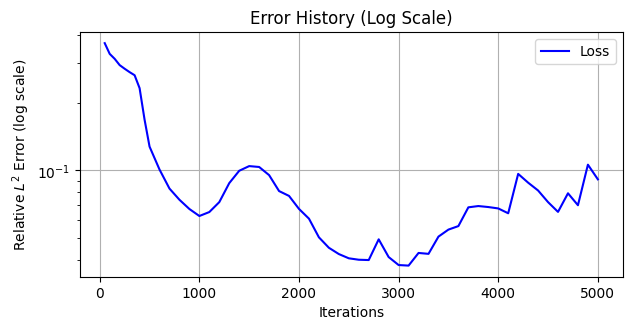

RL2 error: 0.09129082
Solution:


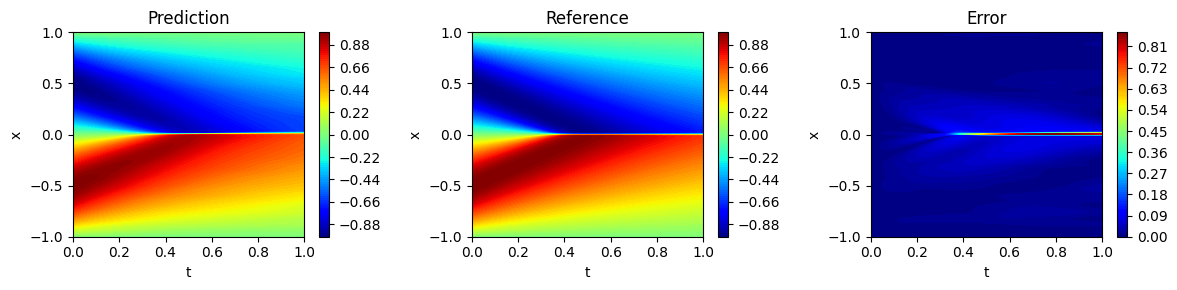

In [18]:
# Adjusting the plot to use a log scale for both loss and error
plt.figure(figsize=(12, 6))
# Plotting loss history with log scale
plt.subplot(2, 2, 1)
plt.plot(all_its, all_errors, label='Loss', color='blue')
plt.yscale('log')
plt.xlabel('Iterations')
plt.ylabel('Relative $L^2$ Error (log scale)')
plt.title('Error History (Log Scale)')
plt.grid(True)
plt.legend()

# Show the plots
plt.tight_layout()
plt.savefig('Loss_Adam.png')
plt.show()



error = relative_l2(apply_fn(params, t, x), u_gt)
print(f'RL2 error: {error:.8f}')


it=-1
print('Solution:')
u = apply_fn(params, t, x)
u = u.reshape(T.shape)
lambdas_grid=all_lambdas[it]
idx_it=all_idx[it]

# Plotting code
fig = plt.figure(figsize=(12, 3))
levels=100
# Scatter plot for collocation, initial, and boundary points
ax1 = fig.add_subplot(131)
contour = ax1.contourf(T, X, u, cmap='jet', levels=levels)  # Filled contour plot with 50 levels
fig.colorbar(contour)  # Add color bar to show scale
ax1.set_xlabel('t')
ax1.set_ylabel('x')
ax1.set_title('Prediction')

# Surface plot for Exact solution
ax2 = fig.add_subplot(132)
contour = ax2.contourf(T, X, Exact0, cmap='jet', levels=levels)  # Filled contour plot with 50 levels
fig.colorbar(contour)  # Add color bar to show scale
ax2.set_xlabel('t')
ax2.set_ylabel('x')
ax2.set_title('Reference')
# Surface plot for Exact solution
ax3 = fig.add_subplot(133)
contour = ax3.contourf(T, X, np.abs(Exact0-u), cmap='jet', levels=levels)  # Filled contour plot with 50 levels
fig.colorbar(contour)  # Add color bar to show scale
ax3.set_xlabel('t')
ax3.set_ylabel('x')
ax3.set_title('Error')
plt.tight_layout()

plt.savefig('Errorss_Adam.png',dpi=300)
plt.show()
#

## Cell 15: Preparation for Second-Order Optimization (SSBroyden)


In [19]:
gamma = args.gamma_bfgs
eta = 1-gamma
initial_weights, unflatten_func = ravel_pytree(params)
params_test=unflatten_func(initial_weights)
error = relative_l2(apply_fn(params, t, x), u_gt)
print(f'RL2 error: {error:.8f}')
error = relative_l2(apply_fn(params_test, t, x), u_gt)
print(f'Reconstructed parameters: RL2 error: {error:.8f}')
X=np.hstack([tc.astype(jnp.float64),xc.astype(jnp.float64)])

RL2 error: 0.09129082
Reconstructed parameters: RL2 error: 0.09129082


## Cell 16: Defining the Loss Functions for Second-Order Optimization

In [20]:
@partial(jax.jit, static_argnums=(0,))

def apply_model_2nd_Order(apply_fn, params, nu, *train_data):
    t, x, _, _, _ = train_data  # ti, xi, ui are not used
    def loss_pde(params):
        # Compute residuals
        residuals = PDE_residuals(params, t, x, nu, apply_fn)
        pde_loss = jnp.mean((residuals)**2)
        return pde_loss
    loss_value = loss_pde(params)
    return loss_value
@partial(jax.jit, static_argnums=(0,))
def update_lambdas(apply_fn,params,lambdas,gamma,eta,tc,xc,it, nu):
    t,x=tc,xc
    def get_lambdas(params, lambdas):
        residuals = PDE_residuals(params, t, x, nu, apply_fn)
        # Update lambdas
        r_i_norm = lax.stop_gradient(jnp.abs(residuals))
        new_lambdas = update_weights_fn(r_i_norm,lambdas, it,
                                          gamma=gamma,
                                          eta=eta)
        return new_lambdas
    new_lambdas=get_lambdas(params, lambdas)
    return new_lambdas
@partial(jax.jit, static_argnums=(1, 2))

def loss_and_gradient(weights, N_arg, unflatten_func_arg, *train_data_tuple_arg):
    flat_jax_array = weights
    params_current = unflatten_func_arg(flat_jax_array)
    *actual_train_data, nu = train_data_tuple_arg
    loss_val_jax = apply_model_2nd_Order(N_arg, params_current, nu, *actual_train_data)
    return loss_val_jax
#

## Cell 17: The SSBroyden Optimization Step Function

In [21]:
@partial(jax.jit, static_argnames=("apply_fn", "unflatten_func", "batch_size", "gamma", "eta", "k", "c", "static_options"))
def SSBroyden_step(
    initial_weights, H0, key,
    tc, xc, ti, xi, ui, lambdas,
apply_fn, unflatten_func, batch_size, gamma, eta, k, c, static_options, it, nu):
    key, subkey = jax.random.split(key)
    # 2. Update Lambdas ...
    params_it = unflatten_func(initial_weights)
    updated_lambdas = update_lambdas(apply_fn, params_it, lambdas, gamma, eta, tc, xc, it, nu)
    _, current_train_data_tuple = sample_points_pdf(
        subkey, batch_size, updated_lambdas, tc, xc, ti, xi, ui, k, c
    )
    # 4. Prepare the full options dictionary for minimize
    current_options = dict(static_options)
    current_options['initial_H'] = H0
    # 5. Run the SSBroyden optimization for Nchange steps
    result = minimize(
        fun=loss_and_gradient,
        x0=initial_weights,
args=(apply_fn, unflatten_func, *current_train_data_tuple, nu),
        method='BFGS', # SSBroyden version of BFGs
        options=current_options)
    # 6. Recycle the Hessian purely
    new_H0 = result.hess_inv
    new_H0 = (new_H0 + jnp.transpose(new_H0)) / 2
    try:
        L = jnp.linalg.cholesky(new_H0)
        is_failed = jnp.any(jnp.isnan(L))
        final_H0 = jax.lax.cond(
            is_failed,
            lambda op: jnp.eye(op.shape[0], dtype=op.dtype),
            lambda op: op,
            operand=new_H0)
    except LinAlgError:
        final_H0 = jnp.eye(new_H0.shape[0], dtype=new_H0.dtype)
    return result.x, final_H0, key, result.fun, result.nit, updated_lambdas

## Cell 18: Main SSBroyden Training Loop

In [22]:
# Direct training at target viscosity
nu = 1/(100*jnp.pi)
SSBroyden_Iterations = 100000

## SSBroyden Hyperparameters
static_options = static_options_SSBroyden
static_options['maxiter'] = Nchange
static_options_tuple = tuple(static_options.items())

# Training Setup
effective_steps = 0
Adam_Steps = all_its[-1]
num_outer_iterations = SSBroyden_Iterations // Nchange

# Initialize Hessian once
H0 = jnp.eye(len(initial_weights), dtype=jnp.float64)

best_res_mean = np.inf
best_weights = initial_weights
# -------------------------------------------------

print(f"\nStarting SSBroyden Training: {SSBroyden_Iterations} iterations at nu = {nu}")
pbar = tqdm(range(num_outer_iterations), desc=f"SSBroyden (nu={nu:.1e})")

# Single Optimization Loop
for it in pbar:
    try:
        # 1. Optimization Step
        initial_weights, H0, key, loss_val, nit, lambdas = SSBroyden_step(
            initial_weights, H0, key,
            tc, xc, ti, xi, ui, lambdas,
            apply_fn, unflatten_func, batch_size, gamma, eta, k_samp_bfgs, c_samp_bfgs,
            static_options_tuple, it, nu
        )
        effective_steps += nit
        current_params_for_eval = unflatten_func(initial_weights)

        # 2. Evaluation
        # Note: We assume u_gt is available/shaped correctly for the batch t, x here.
        # If t, x are full grid, ensure u_gt matches.
        u_pred_it = apply_fn(current_params_for_eval, t, x)
        error = relative_l2(u_pred_it, u_gt)

        # 3. Calculate Residuals (Used for metrics AND stability check)
        residuals = PDE_residuals(current_params_for_eval, tc, xc, nu, apply_fn)
        current_res_mean = jnp.mean(jnp.abs(residuals))

        # 4. Divergence/Instability Check
        # Merged your condition (loss > 1e10) with the safety checks (isnan)
        error_val = float(error)
        loss_chk = float(loss_val)
        res_mean_chk = float(current_res_mean)

        if (loss_chk > 1e10 or np.isnan(loss_chk) or
            error_val > 1.e3 or np.isnan(res_mean_chk)):
            raise ValueError(f"Divergence detected (Loss={loss_chk:.2e}, Error={error_val:.2e}, ResMean={res_mean_chk:.2e})")

        # 5. Metrics Calculation
        error_vec = u_pred_it - u_gt
        # Explicit cast to np.array to ensure Scipy handles JAX arrays correctly
        L_infty = scipy.linalg.norm(np.array(error_vec.flatten()), ord=np.inf)
        L_2 = scipy.linalg.norm(np.array(error_vec.flatten()), ord=2)

        # Store custom residual metrics
        var_hist.append(jnp.var(residuals))
        linf_hist.append(jnp.max(jnp.abs(residuals)))

        all_errors.append(error)
        all_loss.append(loss_val)
        all_its.append(effective_steps + Adam_Steps)
        all_L_infty.append(L_infty)
        all_L_2.append(L_2)

        # 6. Save Best State (Lowest Mean Residual)
        if current_res_mean < best_res_mean:
            best_res_mean = current_res_mean
            best_weights = initial_weights

        pbar.set_postfix({
            'It': effective_steps,
            'Loss': f'{loss_val:.3e}',
            'RL2': f'{float(error):.3e}',
            'nu': f'{nu:.1e}',
            'ResMean': f'{float(current_res_mean):.3e}', # Added for visibility
        })

    except (ValueError, FloatingPointError, KeyboardInterrupt) as e:
        print(f"\n[CRASH/STOP PREVENTED] Instability or Stop at It {effective_steps + Adam_Steps}")
        print(f"Reason: {e}")
        print(">> Restoring best parameters and stopping training.")
        initial_weights = best_weights
        current_params_for_eval = unflatten_func(initial_weights)
        break
# Ensure the model ends with the best found parameters, even if loop finished normally
print("Restoring optimal parameters (lowest mean residual)...")
initial_weights = best_weights
current_params_for_eval = unflatten_func(initial_weights)
# --------------------------------


Starting SSBroyden Training: 100000 iterations at nu = 0.0031830988618379067


SSBroyden (nu=3.2e-03): 100%|██████████| 1000/1000 [46:34<00:00,  2.79s/it, It=64232, Loss=2.030e-14, RL2=1.606e-08, nu=3.2e-03, ResMean=8.381e-08]

Restoring optimal parameters (lowest mean residual)...


## Cell 19: Final Visualization & Error Reporting

Solution:
Calculating PDE residuals for plotting...
Residuals calculated. Min: 2.1047269829765902e-13, Max: 6.2402927483162784e-06


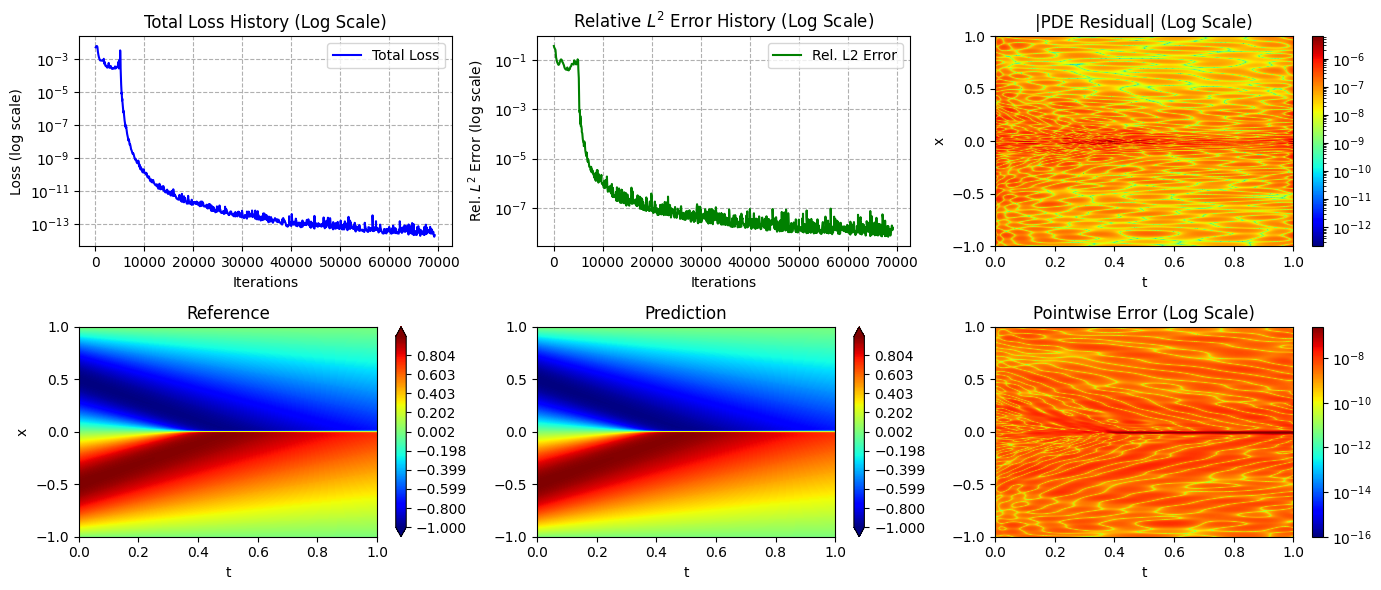

Minimum achieved RL2 error: 6.911864712940323e-09


In [23]:
T, X = np.meshgrid(t0, x0)
# Ground Truth (already float64 due to T, X)
t = T.flatten()[:,None]
x = X.flatten()[:,None]
u_gt = Exact0.flatten()[:,None]

print('Solution:')
# Recalculate u using the RESTORED best parameters
u = apply_fn(current_params_for_eval, t, x)
u = u.reshape(T.shape)

fig, axes = plt.subplots(2, 3, figsize=(14, 6))

# Row 1
ax_tl = axes[0, 0]
ax_tl.plot(all_its, all_loss, label='Total Loss', color='blue')
ax_tl.set_yscale('log')
ax_tl.set_title('Total Loss History (Log Scale)')
ax_tl.set_xlabel('Iterations')
ax_tl.set_ylabel('Loss (log scale)')
ax_tl.grid(True, which="both", ls="--")
ax_tl.legend()

ax_tm = axes[0, 1]
ax_tm.plot(all_its, all_errors, label='Rel. L2 Error', color='green')
ax_tm.set_yscale('log')
ax_tm.set_title('Relative $L^2$ Error History (Log Scale)')
ax_tm.set_xlabel('Iterations')
ax_tm.set_ylabel('Rel. $L^2$ Error (log scale)')
ax_tm.grid(True, which="both", ls="--")
ax_tm.legend()

ax_tr = axes[0, 2]
print("Calculating PDE residuals for plotting...")
# Use 'nu' here as defined in the training block
res = PDE_residuals(current_params_for_eval, t, x, nu, apply_fn)
res_grid = jnp.abs(res.reshape(T.shape))
print(f"Residuals calculated. Min: {res_grid.min()}, Max: {res_grid.max()}")
res_log_norm = colors.LogNorm(vmin=max(1e-16, res_grid.min()), vmax=max(1e-16, res_grid.max()))
mesh_res = ax_tr.pcolormesh(T, X, res_grid, cmap='jet', norm=res_log_norm, shading='gouraud')
fig.colorbar(mesh_res, ax=ax_tr)
ax_tr.set_xlabel('t')
ax_tr.set_ylabel('x')
ax_tr.set_title('|PDE Residual| (Log Scale)')

# Row 2
global_vmin = np.min([u, Exact0])
global_vmax = np.max([u, Exact0])
shared_levels = np.linspace(global_vmin, global_vmax, 500)

ax_bl = axes[1, 0]
contour1 = ax_bl.contourf(T, X, Exact0, cmap='jet', levels=shared_levels, extend='both')
fig.colorbar(contour1, ax=ax_bl)
ax_bl.set_xlabel('t')
ax_bl.set_ylabel('x')
ax_bl.set_title('Reference')

ax_bm = axes[1, 1]
contour2 = ax_bm.contourf(T, X, u, cmap='jet', levels=shared_levels, extend='both')
fig.colorbar(contour2, ax=ax_bm)
ax_bm.set_xlabel('t')
ax_bm.set_title('Prediction')

ax_br = axes[1, 2]
error_data = np.abs(Exact0 - u)
err_log_norm = colors.LogNorm(vmin=max(1e-16, error_data.min()), vmax=max(1e-16, error_data.max()))
mesh_err = ax_br.pcolormesh(T, X, error_data, cmap='jet', norm=err_log_norm, shading='gouraud')
fig.colorbar(mesh_err, ax=ax_br)
ax_br.set_xlabel('t')
ax_br.set_title('Pointwise Error (Log Scale)')

plt.tight_layout()
plt.savefig(f'summary_all_{METHOD}.png', dpi=150)
plt.show()
print('Minimum achieved RL2 error:', np.nanmin(all_errors))


## Cell 20: Save Prediction Results to .npz File

In [24]:
print("Saving prediction data to .npz file...")

# Ensure data is in standard NumPy format for saving
t_vec_save = np.asarray(t0).flatten()
x_vec_save = np.asarray(x0).flatten()

# Save the full 2D grids
T_save = np.asarray(T)
X_save = np.asarray(X)

u_pred_save = np.asarray(u)
res_field_save = np.asarray(res_grid)
u_ref_save = np.asarray(Exact0)

save_filename = f'burgers_pred_{METHOD}.npz'

np.savez(save_filename,
             t_vec=t_vec_save,
             x_vec=x_vec_save,
             T=T_save,
             X=X_save,
             u=u_pred_save,
             u_exact=u_ref_save,
             residual_field=res_field_save,
             loss_history=np.asarray(all_loss),
             error_history=np.asarray(all_errors),
             Linf_error_history=np.asarray(all_L_infty), # Added from lists
             L2_error_history=np.asarray(all_L_2),       # Added from lists
             var_hist=np.asarray(var_hist),
             linf_hist=np.asarray(linf_hist),
             all_its=np.asarray(all_its))

print(f"Data saved successfully to {save_filename}")
print(f"Saved keys: t_vec, x_vec, T, X, u, u_exact, residual_field, loss_history, error_history, Linf_error_history, L2_error_history, var_hist, linf_hist")

Saving prediction data to .npz file...
Data saved successfully to burgers_pred_exponential.npz
Saved keys: t_vec, x_vec, T, X, u, u_exact, residual_field, loss_history, error_history, Linf_error_history, L2_error_history, var_hist, linf_hist


# Reference
If you use this code please consider citing our work.

```bibtex
@article{toscano2026variational,
  title={A variational framework for residual-based adaptivity in neural PDE solvers and operator learning},
  author={Toscano, Juan Diego and Chen, Daniel T and Oommen, Vivek and Darbon, J{\'e}r{\^o}me and Karniadakis, George Em},
  journal={npj Artificial Intelligence},
  volume={2},
  pages={32},
  year={2026},
  doi={10.1038/s44387-026-00084-4},
  url={https://doi.org/10.1038/s44387-026-00084-4}
}
```